<a href="https://www.kaggle.com/code/alexxx8080/eeg-imagery-classification?scriptVersionId=304993570" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install mne torch numpy matplotlib scikit-learn scipy tqdm gdown -q

import numpy as np
import mne
import re
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import itertools
import pandas as pd
from tqdm import tqdm
from mne.datasets import eegbci
from mne.io import read_raw_edf
from scipy.signal import welch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import os
import math
import random
import gdown

SAVE_DIR = '/kaggle/working/EEG_Results/'
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Save dir: {SAVE_DIR}")
print("Setup complete!")

Save dir: /kaggle/working/EEG_Results/
Setup complete!


In [2]:
###file id
FILE_IDS = {
    'X_big.npy':       '1f7IRPTfBTJTcYxEHj_IhQmbUcDqwZJ-b',
    'y_big.npy':       '14CL6brcbJvn9r8KctTbtH8Hk1j3r9AKC',
    'subject_ids.npy': '1GQ-ZKEAurKr2_WYLFf4-uY0bICSck4Xg',
    'X_feat.npy':      '1mOHPV8_D_pcTSLfX1_0SlRsLmAOAHl-F',
}

print("Downloading files from Google Drive...")
for filename, file_id in FILE_IDS.items():
    output = os.path.join(SAVE_DIR, filename)
    if os.path.exists(output):
        print(f"  {filename} already exists, skipping")
        continue
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output, quiet=False)
    print(f"  {filename} downloaded ✓")

print("\nAll files ready!")
print(f"Files in {SAVE_DIR}:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"  {f}: {size:.1f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1f7IRPTfBTJTcYxEHj_IhQmbUcDqwZJ-b
From (redirected): https://drive.google.com/uc?id=1f7IRPTfBTJTcYxEHj_IhQmbUcDqwZJ-b&confirm=t&uuid=4b53fe70-f853-4cb5-97eb-9d2a79686507
To: /kaggle/working/EEG_Results/X_big.npy
100%|██████████| 234M/234M [00:02<00:00, 92.0MB/s]


  X_big.npy downloaded ✓


Downloading...
From: https://drive.google.com/uc?id=14CL6brcbJvn9r8KctTbtH8Hk1j3r9AKC
To: /kaggle/working/EEG_Results/y_big.npy
100%|██████████| 152k/152k [00:00<00:00, 64.1MB/s]


  y_big.npy downloaded ✓


Downloading...
From: https://drive.google.com/uc?id=1GQ-ZKEAurKr2_WYLFf4-uY0bICSck4Xg
To: /kaggle/working/EEG_Results/subject_ids.npy
100%|██████████| 152k/152k [00:00<00:00, 67.8MB/s]


  subject_ids.npy downloaded ✓


Downloading...
From: https://drive.google.com/uc?id=1mOHPV8_D_pcTSLfX1_0SlRsLmAOAHl-F
To: /kaggle/working/EEG_Results/X_feat.npy
100%|██████████| 13.2M/13.2M [00:00<00:00, 111MB/s]

  X_feat.npy downloaded ✓

All files ready!
Files in /kaggle/working/EEG_Results/:
  X_big.npy: 234.1 MB
  X_feat.npy: 13.2 MB
  subject_ids.npy: 0.2 MB
  y_big.npy: 0.2 MB


In [3]:
X_big       = np.load(os.path.join(SAVE_DIR, 'X_big.npy'))
y_big       = np.load(os.path.join(SAVE_DIR, 'y_big.npy'))
subject_ids = np.load(os.path.join(SAVE_DIR, 'subject_ids.npy'))

print(f"X: {X_big.shape}, y: {y_big.shape}")
print(f"Subjects: {len(np.unique(subject_ids))}")
print(f"Class counts — T0:{(y_big==0).sum()} T1:{(y_big==1).sum()} T2:{(y_big==2).sum()}")

X: (19010, 3, 513), y: (19010,)
Subjects: 109
Class counts — T0:9184 T1:4939 T2:4887


In [4]:
X_feat      = np.load(os.path.join(SAVE_DIR, 'X_feat.npy'))
y_big       = np.load(os.path.join(SAVE_DIR, 'y_big.npy'))
subject_ids = np.load(os.path.join(SAVE_DIR, 'subject_ids.npy'))

print(f"Features: {X_feat.shape}")
print(f"Sequence length: {X_feat.shape[1]}")
print(f"Total samples: {len(X_feat)}")

Features: (19010, 29, 3)
Sequence length: 29
Total samples: 19010


In [5]:
# Balance classes
idx_T0 = np.where(y_big == 0)[0]
idx_T1 = np.where(y_big == 1)[0]
idx_T2 = np.where(y_big == 2)[0]

n_keep       = (len(idx_T1) + len(idx_T2)) // 2
idx_T0_keep  = np.random.choice(idx_T0, n_keep, replace=False)
idx_balanced = np.concatenate([idx_T0_keep, idx_T1, idx_T2])

X_bal        = X_feat[idx_balanced]
y_bal        = y_big[idx_balanced]
subjects_bal = subject_ids[idx_balanced]

print("Class counts after balancing:", Counter(y_bal))

# Splitting by subject
unique_subjects = np.unique(subjects_bal)
np.random.shuffle(unique_subjects)

n_subjects     = len(unique_subjects)
train_subjects = unique_subjects[:int(0.70 * n_subjects)]
val_subjects   = unique_subjects[int(0.70 * n_subjects):int(0.85 * n_subjects)]
test_subjects  = unique_subjects[int(0.85 * n_subjects):]

print(f"Train: {len(train_subjects)} subjects | Val: {len(val_subjects)} | Test: {len(test_subjects)}")

train_mask = np.isin(subjects_bal, train_subjects)
val_mask   = np.isin(subjects_bal, val_subjects)
test_mask  = np.isin(subjects_bal, test_subjects)

X_train, y_train = X_bal[train_mask], y_bal[train_mask]
X_val,   y_val   = X_bal[val_mask],   y_bal[val_mask]
X_test,  y_test  = X_bal[test_mask],  y_bal[test_mask]

# Normalize
n_e, n_t, n_c = X_train.shape
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, n_c)).reshape(n_e, n_t, n_c)
X_val   = scaler.transform(X_val.reshape(-1, n_c)).reshape(len(X_val), n_t, n_c)
X_test  = scaler.transform(X_test.reshape(-1, n_c)).reshape(len(X_test), n_t, n_c)

# Tensors
X_train_t = torch.FloatTensor(X_train)
X_val_t   = torch.FloatTensor(X_val)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_val_t   = torch.LongTensor(y_val)
y_test_t  = torch.LongTensor(y_test)

batch_size   = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=batch_size, shuffle=False)

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = X_train.shape[1]

print(f"Device: {device}")
print(f"Sequence length: {SEQ_LEN}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Class counts after balancing: Counter({np.int64(1): 4939, np.int64(0): 4913, np.int64(2): 4887})
Train: 76 subjects | Val: 16 | Test: 17
Device: cuda
Sequence length: 29
Train: (10222, 29, 3) | Val: (2198, 29, 3) | Test: (2319, 29, 3)


In [6]:
###model funtions

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class VanillaRNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=2, num_classes=3, dropout=0.3):
        super().__init__()
        self.rnn     = nn.RNN(input_size, hidden_size, num_layers, batch_first=True,
                              dropout=dropout if num_layers > 1 else 0)
        self.bn      = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out    = out.mean(dim=1)
        out    = self.bn(out)
        out    = self.dropout(out)
        return self.fc(out)


class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=2, num_classes=3, dropout=0.3):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.bn      = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out.mean(dim=1)
        out    = self.bn(out)
        out    = self.dropout(out)
        return self.fc(out)


class CNNModel(nn.Module):
    def __init__(self, input_size=3, seq_len=SEQ_LEN, num_classes=3,
                 dropout=0.5, kernel_size=3, base_filters=32):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(input_size,       base_filters,   kernel_size=kernel_size, padding=pad)
        self.conv2 = nn.Conv1d(base_filters,     base_filters*2, kernel_size=kernel_size, padding=pad)
        self.conv3 = nn.Conv1d(base_filters*2,   base_filters*4, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(base_filters)
        self.bn2   = nn.BatchNorm1d(base_filters*2)
        self.bn3   = nn.BatchNorm1d(base_filters*4)
        self.dropout      = nn.Dropout(dropout)
        self.relu         = nn.ReLU()
        self.adaptive_pool = nn.AdaptiveAvgPool1d(4)
        self.fc1 = nn.Linear(base_filters*4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.adaptive_pool(x)
        x = x.flatten(1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

class TransformerModel(nn.Module):
    def __init__(self, input_size=3, seq_len=SEQ_LEN, num_classes=3,
                 d_model=128, nhead=8, num_layers=3, dropout=0.4):
        super().__init__()
        self.input_proj  = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len + 10)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)


# Sanity check
test_input = torch.randn(8, SEQ_LEN, 3).to(device)
for name, m in [("RNN", VanillaRNN()), ("LSTM", LSTMModel()),
                ("CNN", CNNModel()),   ("Transformer", TransformerModel())]:
    out = m.to(device)(test_input)
    print(f"{name}: output shape {out.shape} ✓")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RNN: output shape torch.Size([8, 3]) ✓
LSTM: output shape torch.Size([8, 3]) ✓
CNN: output shape torch.Size([8, 3]) ✓
Transformer: output shape torch.Size([8, 3]) ✓


In [7]:
##train funtions

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001,
                optimizer_type="adam", patience=15, weight_decay=0.01, verbose=True):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == "adam":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, patience_counter, best_state = 0, 0, None
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss    += loss.item()
            train_correct += (out.argmax(1) == y_batch).sum().item()
            train_total   += y_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out  = model(X_batch)
                loss = criterion(out, y_batch)
                val_loss    += loss.item()
                val_correct += (out.argmax(1) == y_batch).sum().item()
                val_total   += y_batch.size(0)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose: print(f"Early stop at epoch {epoch+1} | best val: {best_val_acc:.4f}")
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | train: {train_acc:.4f} | val: {val_acc:.4f} | "
                  f"lr: {optimizer.param_groups[0]['lr']:.6f}")

    model.load_state_dict(best_state)
    t = time.time() - start_time
    if verbose: print(f"Done. Best val: {best_val_acc:.4f} | Time: {t:.1f}s")
    return history, t


def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            correct += (model(X_batch).argmax(1) == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

print("Ready")

Ready


In [8]:
##Sweeps

results = []

##Rnn/LSTM
hidden_sizes    = [64, 128, 256]
num_layers_list = [1, 2]
dropouts        = [0.3, 0.5]
optimizers      = ["adam", "sgd"]
lrs             = [0.001, 0.0005]

configs = list(itertools.product(hidden_sizes, num_layers_list, dropouts, optimizers, lrs))
print(f"RNN/LSTM configs each: {len(configs)}")

for model_type in ["RNN", "LSTM"]:
    for hidden_size, num_layers, dropout, opt, lr in configs:
        print(f"\n{model_type} | hidden={hidden_size} layers={num_layers} "
              f"drop={dropout} opt={opt} lr={lr}")
        model = (VanillaRNN if model_type == "RNN" else LSTMModel)(
            hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
        hist, t = train_model(model, train_loader, val_loader,
                              epochs=80, lr=lr, optimizer_type=opt,
                              weight_decay=0.01, patience=15, verbose=False)
        acc = evaluate_model(model, test_loader)
        print(f"  test_acc={acc:.4f}")
        results.append({
            "model":        model_type,
            "hidden_size":  hidden_size,
            "num_layers":   num_layers,
            "dropout":      dropout,
            "optimizer":    opt,
            "lr":           lr,
            "best_val_acc": max(hist["val_acc"]),
            "test_acc":     acc,
            "train_time":   t
        })
        pd.DataFrame(results).to_csv(
            os.path.join(SAVE_DIR, 'sweep_results_v2.csv'), index=False)

## CNN
cnn_dropouts     = [0.3, 0.5]
cnn_optimizers   = ["adam", "sgd"]
cnn_lrs          = [0.001, 0.0005]
cnn_kernel_sizes = [3, 5, 7]
cnn_filters      = [32, 64] 

for dropout, opt, lr, kernel, filters in itertools.product(
        cnn_dropouts, cnn_optimizers, cnn_lrs, cnn_kernel_sizes, cnn_filters):
    print(f"\nCNN | drop={dropout} opt={opt} lr={lr} kernel={kernel} filters={filters}")
    model = CNNModel(dropout=dropout, kernel_size=kernel, base_filters=filters)
    hist, t = train_model(model, train_loader, val_loader,
                          epochs=80, lr=lr, optimizer_type=opt,
                          weight_decay=0.01, patience=15, verbose=False)
    acc = evaluate_model(model, test_loader)
    print(f"  test_acc={acc:.4f}")
    results.append({
        "model":        "CNN",
        "hidden_size":  filters,
        "num_layers":   3,
        "dropout":      dropout,
        "optimizer":    opt,
        "lr":           lr,
        "kernel_size":  kernel,
        "best_val_acc": max(hist["val_acc"]),
        "test_acc":     acc,
        "train_time":   t
    })
    pd.DataFrame(results).to_csv(
        os.path.join(SAVE_DIR, 'sweep_results_v2.csv'), index=False)


## Transformer
trans_lrs = [0.001, 0.0005, 0.0001]

for num_layers in [2, 3]:
    for d_model, nhead in [(64, 4), (128, 8)]:
        for dropout in [0.3, 0.4]:
            for opt in ["adam", "sgd"]:
                for lr in trans_lrs:
                    print(f"\nTransformer | d={d_model} h={nhead} l={num_layers} "
                          f"drop={dropout} opt={opt} lr={lr}")
                    model = TransformerModel(d_model=d_model, nhead=nhead,
                                            num_layers=num_layers, dropout=dropout)
                    hist, t = train_model(model, train_loader, val_loader,
                                          epochs=80, lr=lr, optimizer_type=opt,
                                          weight_decay=0.01, patience=15, verbose=False)
                    acc = evaluate_model(model, test_loader)
                    print(f"  test_acc={acc:.4f}")
                    results.append({
                        "model":        "Transformer",
                        "hidden_size":  d_model,
                        "num_layers":   num_layers,
                        "dropout":      dropout,
                        "optimizer":    opt,
                        "lr":           lr,
                        "best_val_acc": max(hist["val_acc"]),
                        "test_acc":     acc,
                        "train_time":   t
                    })
                    pd.DataFrame(results).to_csv(
                        os.path.join(SAVE_DIR, 'sweep_results_v2.csv'), index=False)

print("\nsw eep done")
df_final = pd.read_csv(os.path.join(SAVE_DIR, 'sweep_results_v2.csv'))
print(df_final.groupby('model')['test_acc'].agg(['count', 'max', 'mean']).round(4))

RNN/LSTM configs each: 48

RNN | hidden=64 layers=1 drop=0.3 opt=adam lr=0.001
  test_acc=0.3872

RNN | hidden=64 layers=1 drop=0.3 opt=adam lr=0.0005
  test_acc=0.3859

RNN | hidden=64 layers=1 drop=0.3 opt=sgd lr=0.001
  test_acc=0.3609

RNN | hidden=64 layers=1 drop=0.3 opt=sgd lr=0.0005
  test_acc=0.3454

RNN | hidden=64 layers=1 drop=0.5 opt=adam lr=0.001
  test_acc=0.3950

RNN | hidden=64 layers=1 drop=0.5 opt=adam lr=0.0005
  test_acc=0.3790

RNN | hidden=64 layers=1 drop=0.5 opt=sgd lr=0.001
  test_acc=0.3312

RNN | hidden=64 layers=1 drop=0.5 opt=sgd lr=0.0005
  test_acc=0.3264

RNN | hidden=64 layers=2 drop=0.3 opt=adam lr=0.001
  test_acc=0.3855

RNN | hidden=64 layers=2 drop=0.3 opt=adam lr=0.0005
  test_acc=0.4045

RNN | hidden=64 layers=2 drop=0.3 opt=sgd lr=0.001
  test_acc=0.3665

RNN | hidden=64 layers=2 drop=0.3 opt=sgd lr=0.0005
  test_acc=0.3329

RNN | hidden=64 layers=2 drop=0.5 opt=adam lr=0.001
  test_acc=0.3855

RNN | hidden=64 layers=2 drop=0.5 opt=adam lr=0.00

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  test_acc=0.3959

Transformer | d=64 h=4 l=2 drop=0.3 opt=adam lr=0.0005
  test_acc=0.4118

Transformer | d=64 h=4 l=2 drop=0.3 opt=adam lr=0.0001
  test_acc=0.3980

Transformer | d=64 h=4 l=2 drop=0.3 opt=sgd lr=0.001
  test_acc=0.3264

Transformer | d=64 h=4 l=2 drop=0.3 opt=sgd lr=0.0005
  test_acc=0.3376

Transformer | d=64 h=4 l=2 drop=0.3 opt=sgd lr=0.0001
  test_acc=0.3282

Transformer | d=64 h=4 l=2 drop=0.4 opt=adam lr=0.001
  test_acc=0.3877

Transformer | d=64 h=4 l=2 drop=0.4 opt=adam lr=0.0005
  test_acc=0.3877

Transformer | d=64 h=4 l=2 drop=0.4 opt=adam lr=0.0001
  test_acc=0.3855

Transformer | d=64 h=4 l=2 drop=0.4 opt=sgd lr=0.001
  test_acc=0.3368

Transformer | d=64 h=4 l=2 drop=0.4 opt=sgd lr=0.0005
  test_acc=0.3299

Transformer | d=64 h=4 l=2 drop=0.4 opt=sgd lr=0.0001
  test_acc=0.3437

Transformer | d=128 h=8 l=2 drop=0.3 opt=adam lr=0.001
  test_acc=0.3950

Transformer | d=128 h=8 l=2 drop=0.3 opt=adam lr=0.0005
  test_acc=0.3997

Transformer | d=128 h=8 l=2

In [9]:
df = pd.read_csv(os.path.join(SAVE_DIR, 'sweep_results_v2.csv'))

# Best config per model
best_configs = {}
for m in ["RNN", "LSTM", "CNN", "Transformer"]:
    best_configs[m] = df[df["model"] == m].sort_values("test_acc", ascending=False).iloc[0]
    print(f"{m} best: {best_configs[m].to_dict()}")

def get_best_model(model_name, cfg):
    if model_name == "RNN":
        return VanillaRNN(
            hidden_size=int(cfg.hidden_size),
            num_layers=int(cfg.num_layers),
            dropout=float(cfg.dropout))
    elif model_name == "LSTM":
        return LSTMModel(
            hidden_size=int(cfg.hidden_size),
            num_layers=int(cfg.num_layers),
            dropout=float(cfg.dropout))
    elif model_name == "CNN":
        return CNNModel(
            dropout=float(cfg.dropout),
            kernel_size=int(cfg.kernel_size) if 'kernel_size' in cfg.index and pd.notna(cfg.kernel_size) else 3,
            base_filters=int(cfg.hidden_size) if pd.notna(cfg.hidden_size) else 32)
    elif model_name == "Transformer":
        return TransformerModel(
            d_model=int(cfg.hidden_size),
            nhead=8 if int(cfg.hidden_size) == 128 else 4,  # match sweep: d=128→nhead=8, d=64→nhead=4
            num_layers=int(cfg.num_layers),
            dropout=float(cfg.dropout))

histories, models = {}, {}
for name, cfg in best_configs.items():
    print(f"\nRetraining best {name}...")
    m = get_best_model(name, cfg)
    hist, _ = train_model(
        m, train_loader, val_loader,
        epochs=100,
        lr=float(cfg['lr']) if 'lr' in cfg.index and pd.notna(cfg['lr']) else 0.001,
        optimizer_type=str(cfg.optimizer),
        weight_decay=0.01,
        patience=20,
        verbose=True)
    histories[name] = hist
    models[name]    = m
    torch.save(m.state_dict(), os.path.join(SAVE_DIR, f'best_{name.lower()}.pth'))
    print(f"  Saved best_{name.lower()}.pth")


RNN best: {'model': 'RNN', 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.3, 'optimizer': 'adam', 'lr': 0.0005, 'best_val_acc': 0.3898999090081892, 'test_acc': 0.4044846916774471, 'train_time': 41.9298141002655, 'kernel_size': nan}
LSTM best: {'model': 'LSTM', 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3, 'optimizer': 'adam', 'lr': 0.0005, 'best_val_acc': 0.3853503184713376, 'test_acc': 0.3954290642518326, 'train_time': 40.21638178825378, 'kernel_size': nan}
CNN best: {'model': 'CNN', 'hidden_size': 32, 'num_layers': 3, 'dropout': 0.3, 'optimizer': 'adam', 'lr': 0.001, 'best_val_acc': 0.3967242948134667, 'test_acc': 0.4053471323846485, 'train_time': 17.45866060256958, 'kernel_size': 3.0}
Transformer best: {'model': 'Transformer', 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.3, 'optimizer': 'adam', 'lr': 0.0005, 'best_val_acc': 0.3976342129208371, 'test_acc': 0.4118154376886589, 'train_time': 39.47775888442993, 'kernel_size': nan}

Retraining best RNN...
Epoch  10 | train: 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch  10 | train: 0.4122 | val: 0.3817 | lr: 0.000500
Epoch  20 | train: 0.4318 | val: 0.3849 | lr: 0.000500
Epoch  30 | train: 0.4438 | val: 0.3881 | lr: 0.000125
Early stop at epoch 38 | best val: 0.3963
Done. Best val: 0.3963 | Time: 40.4s
  Saved best_transformer.pth


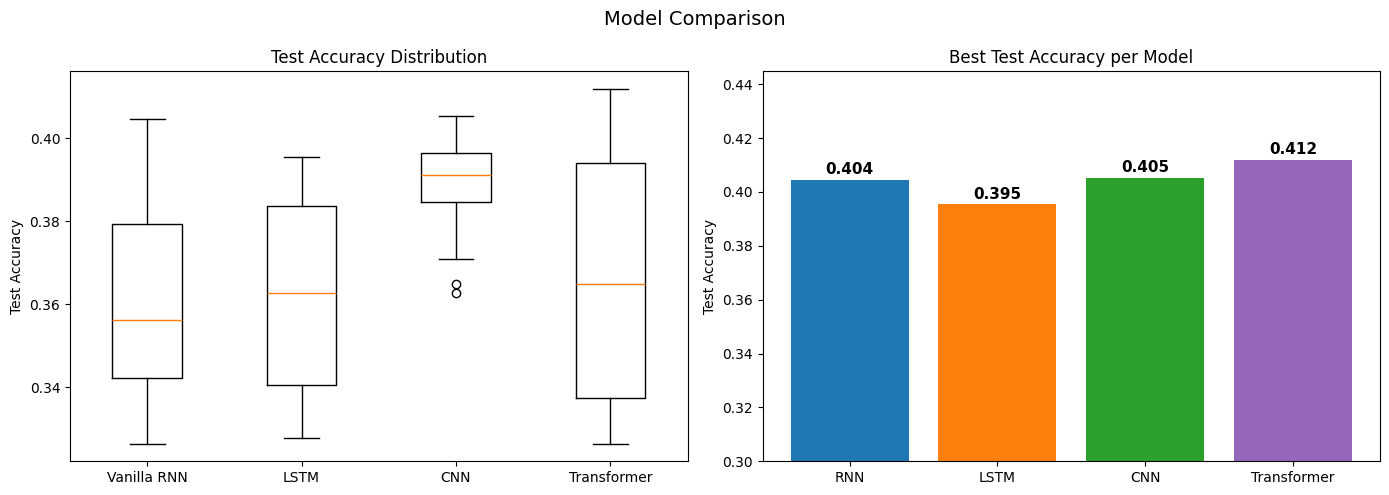

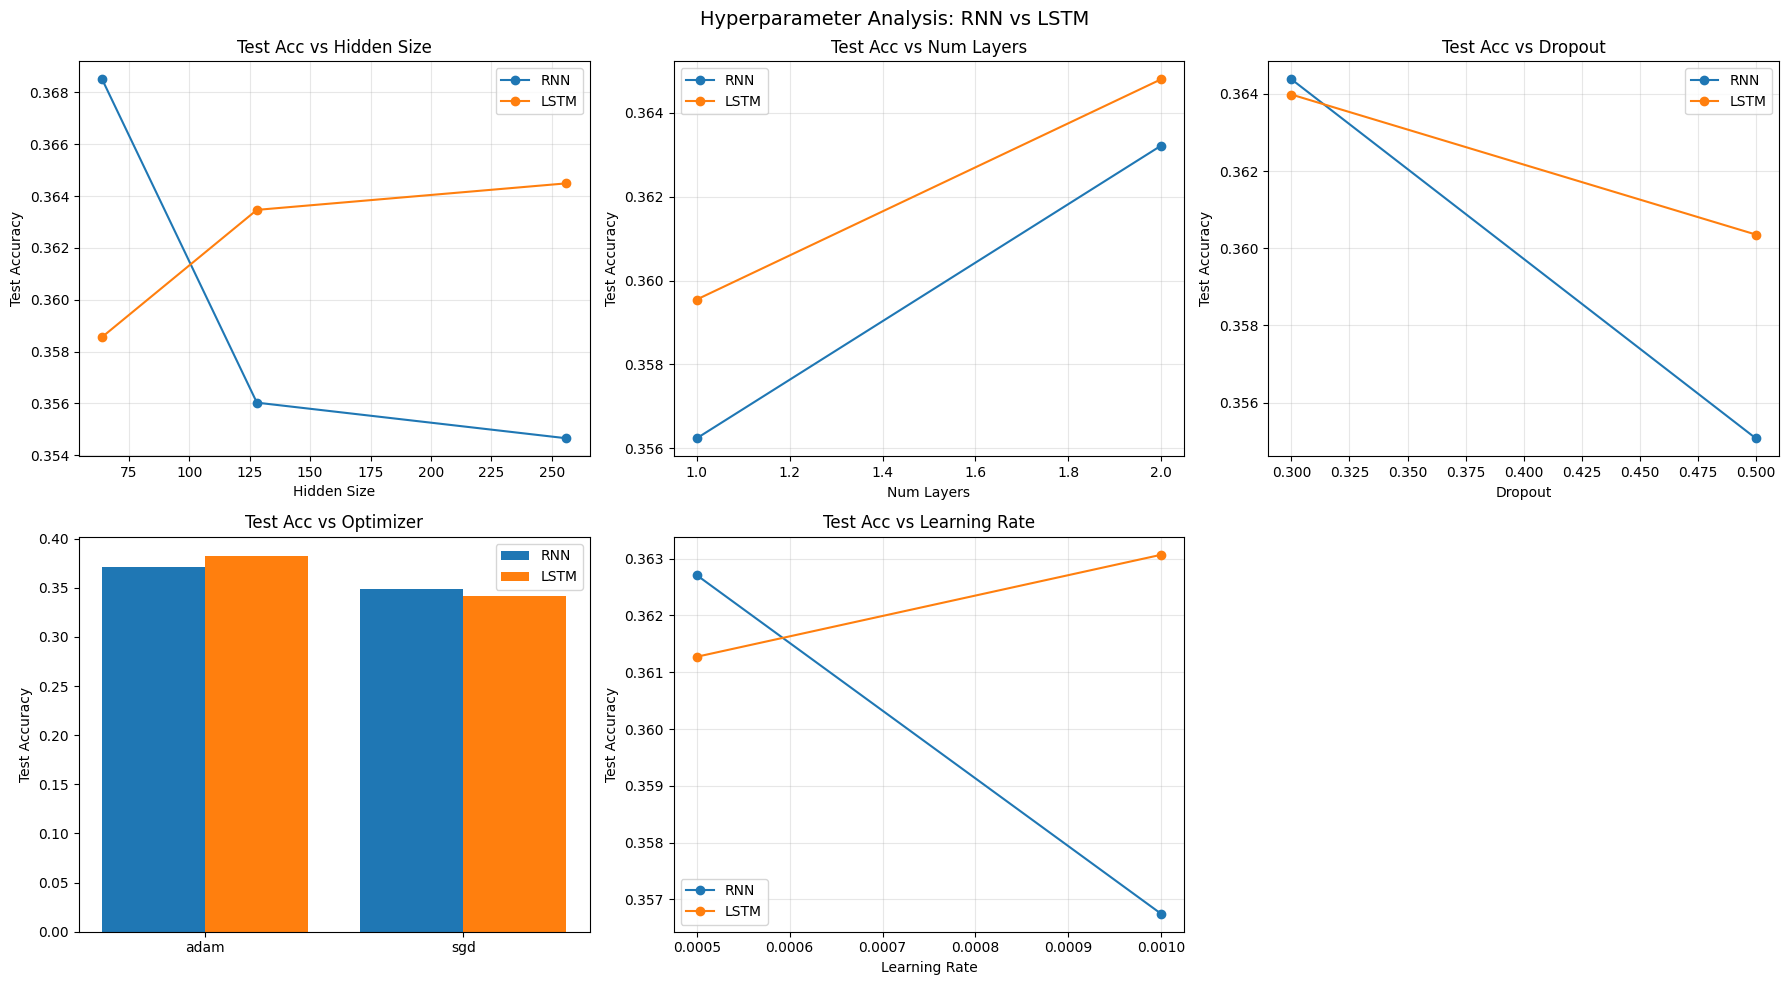

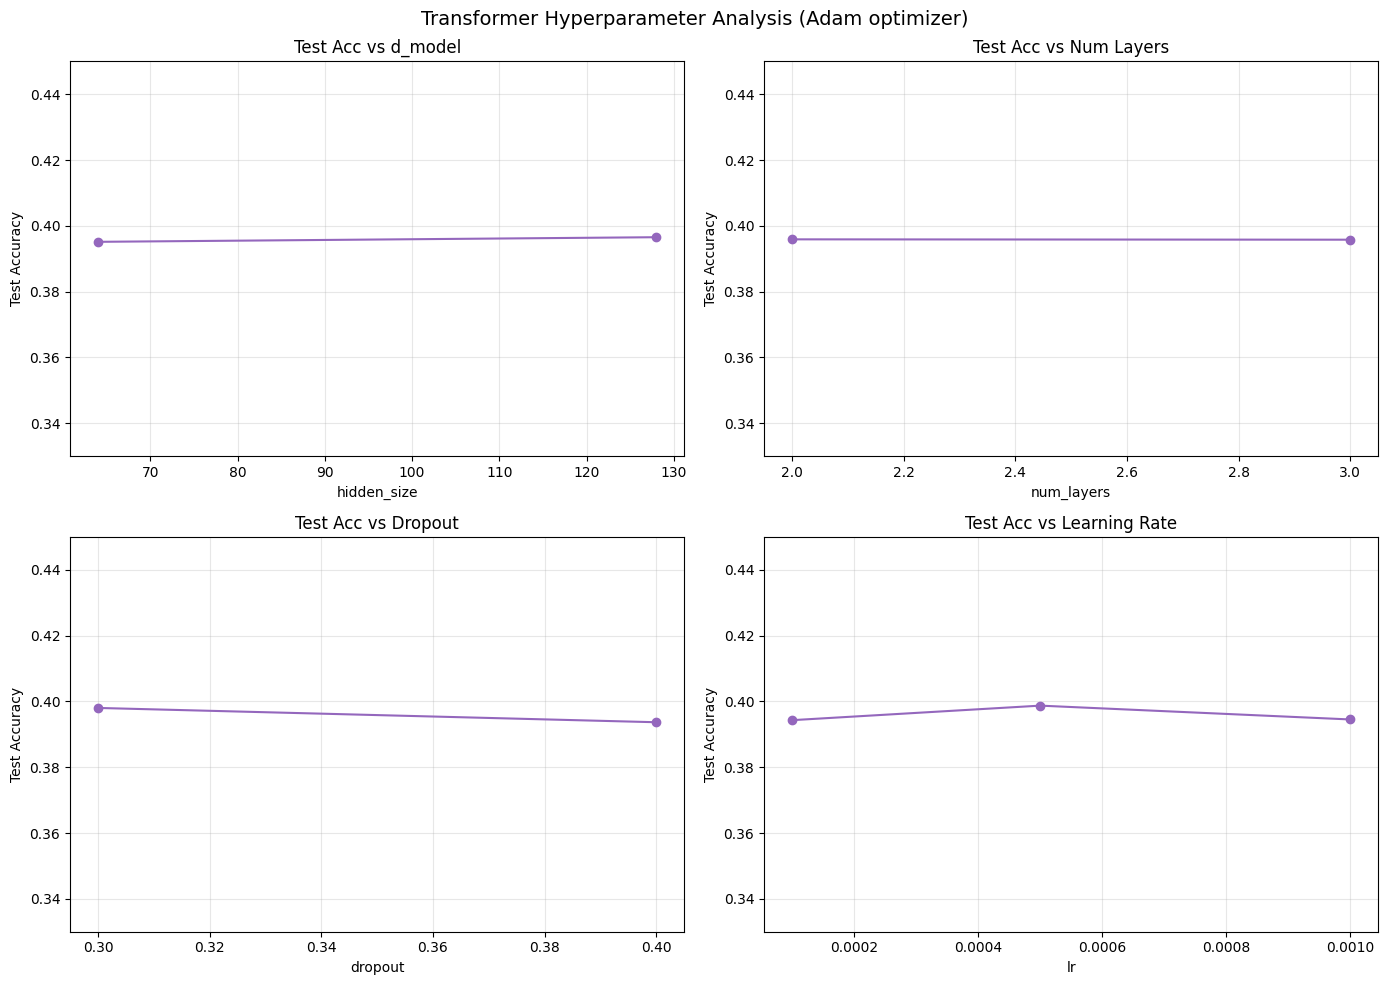

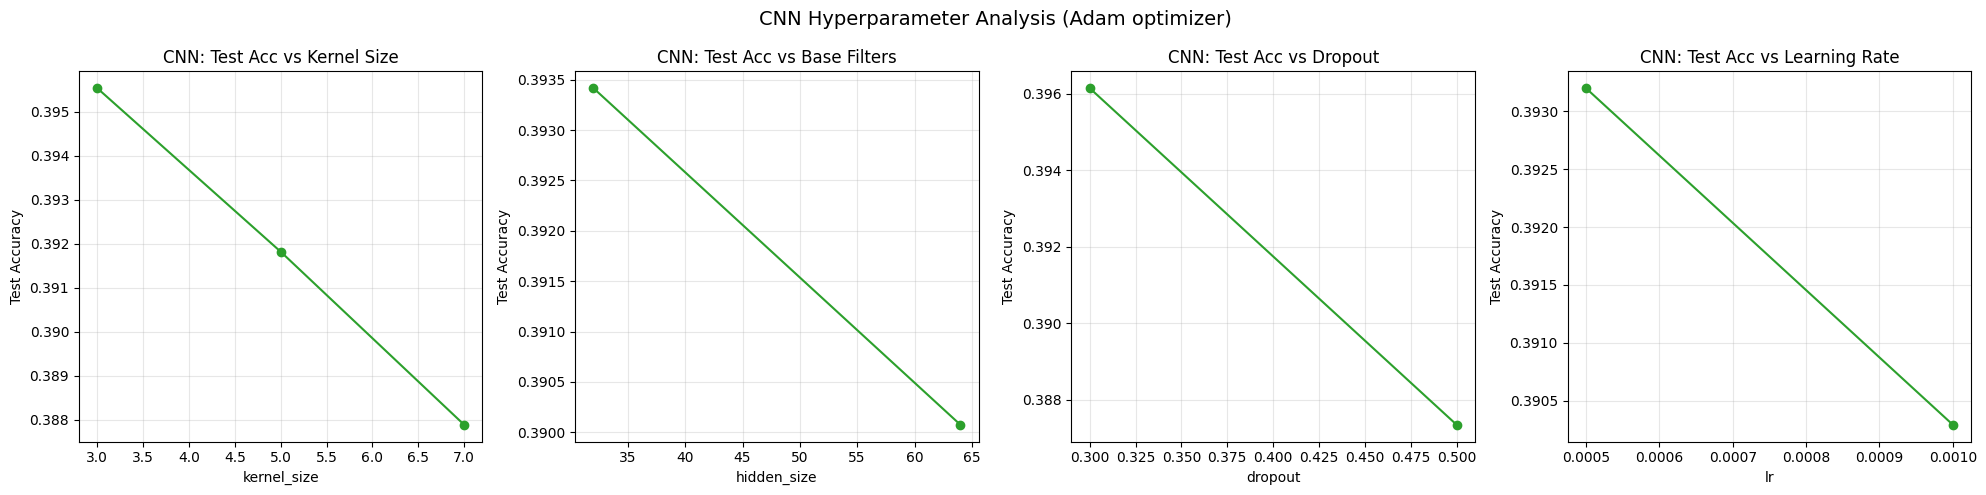

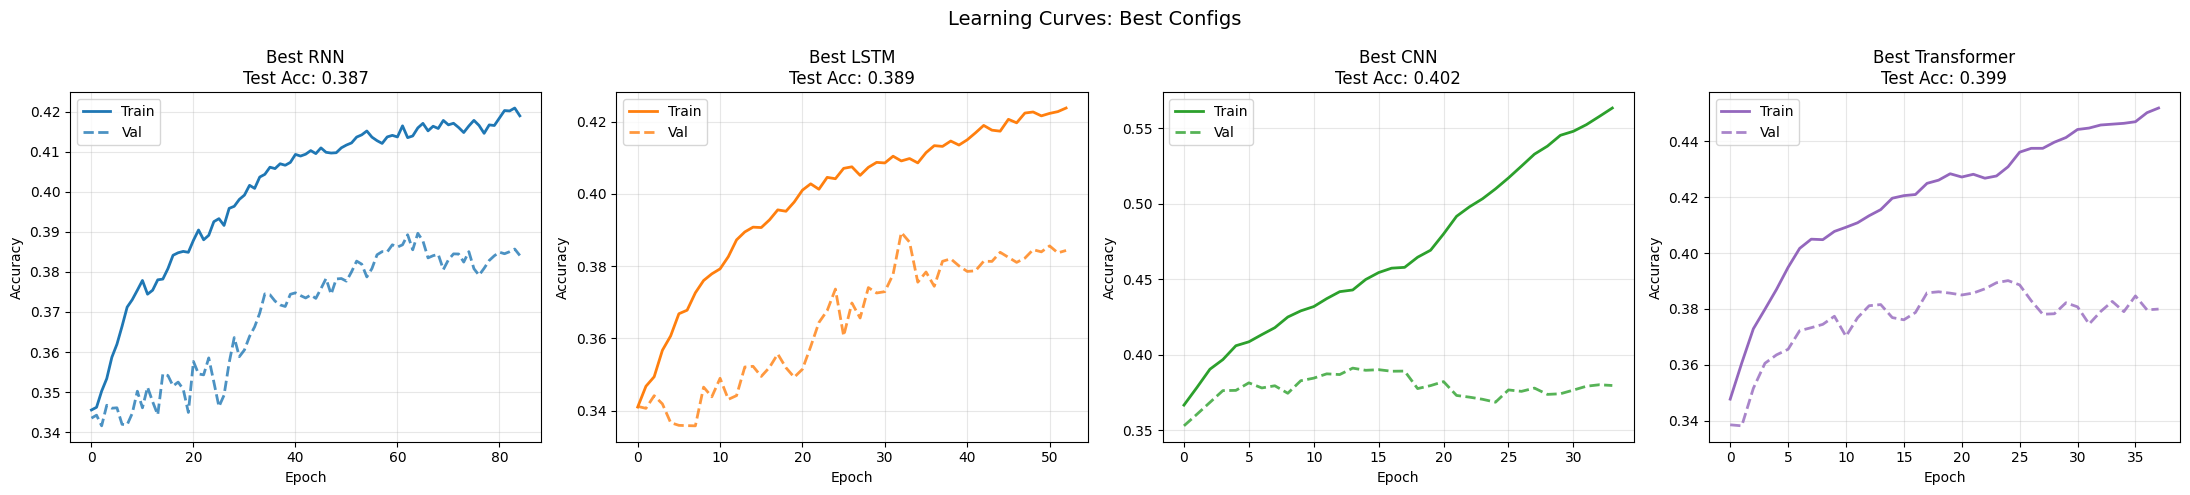

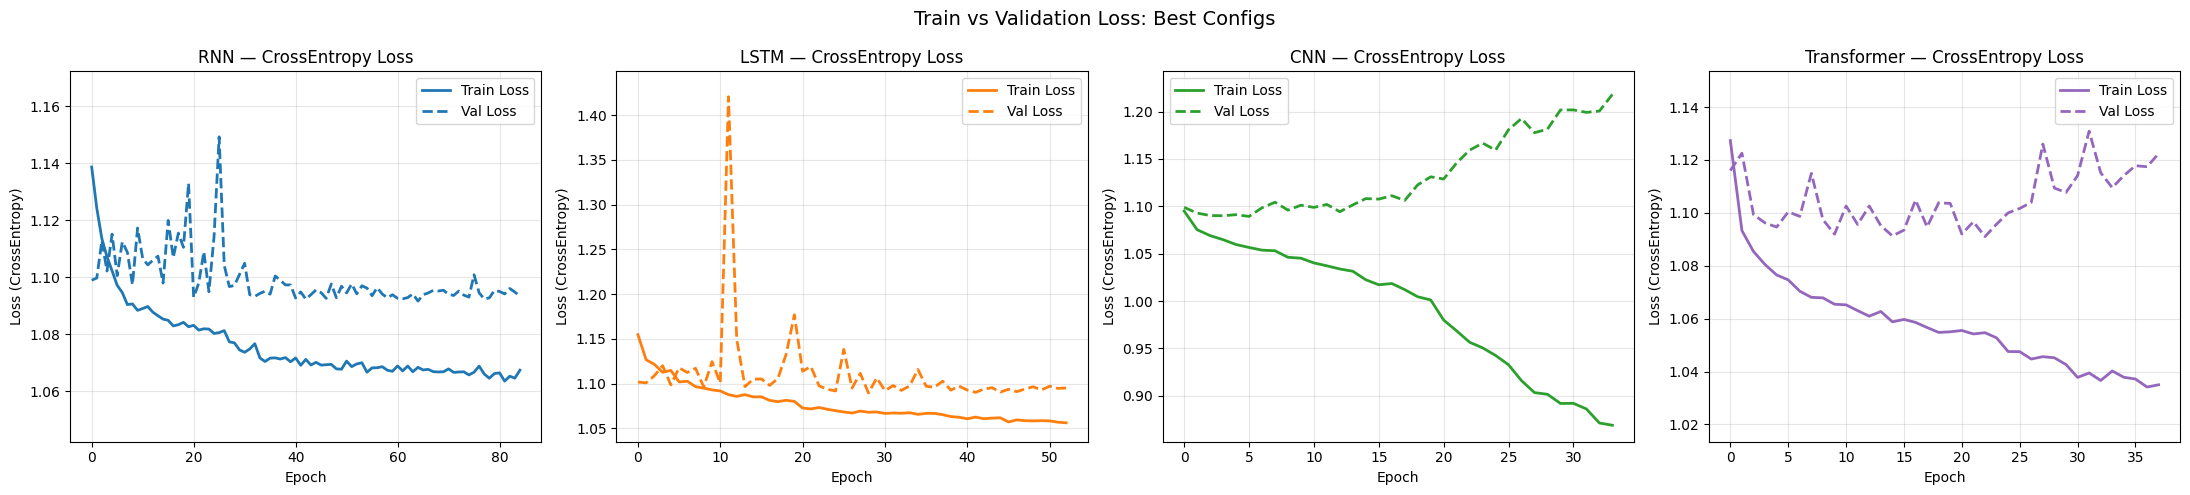

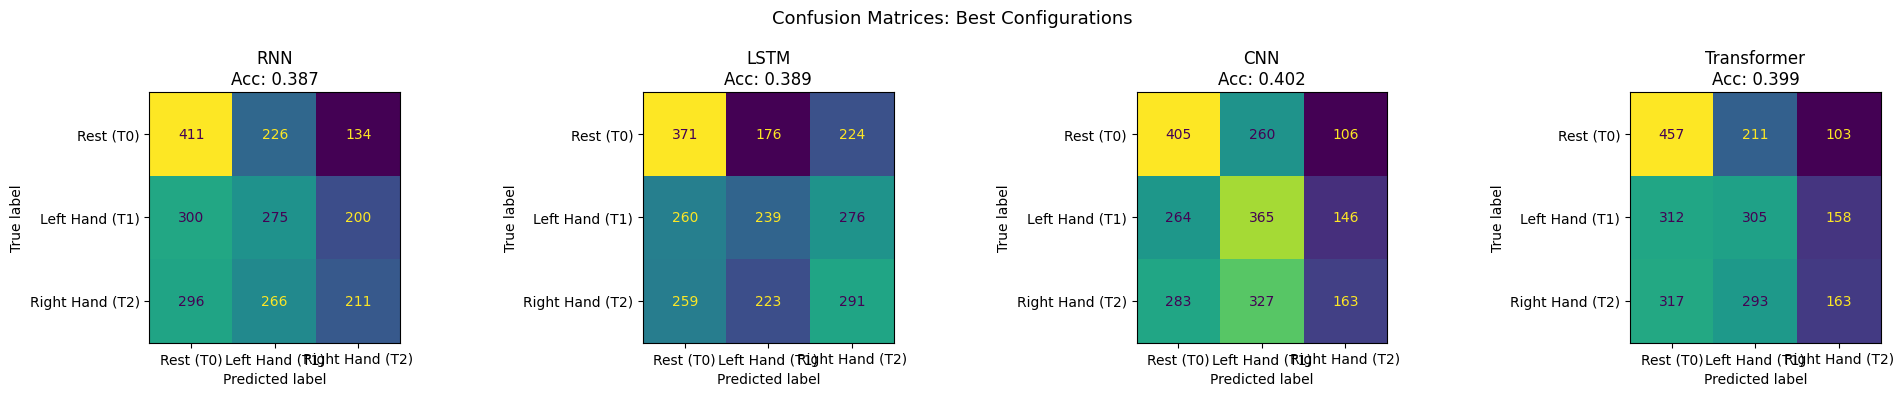

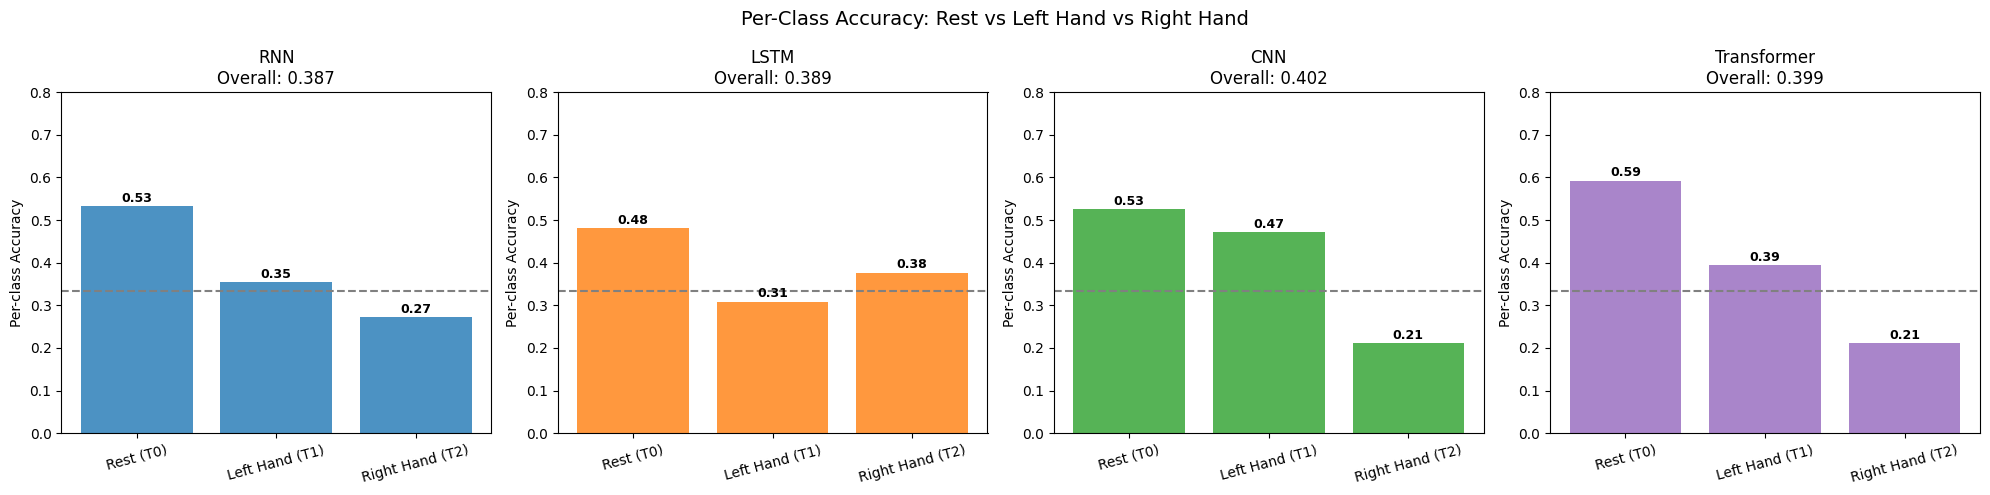

In [10]:
##plots
df = pd.read_csv(os.path.join(SAVE_DIR, 'sweep_results_v2.csv'))
model_names = ["RNN", "LSTM", "CNN", "Transformer"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']

## Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_accs = [df[df["model"] == m]["test_acc"].values for m in model_names]

axes[0].boxplot(model_accs, tick_labels=["Vanilla RNN", "LSTM", "CNN", "Transformer"])
axes[0].set_title("Test Accuracy Distribution")
axes[0].set_ylabel("Test Accuracy")

best_accs = [df[df["model"] == m].sort_values("test_acc", ascending=False).iloc[0]["test_acc"]
             for m in model_names]
bars = axes[1].bar(model_names, best_accs, color=colors)
axes[1].set_title("Best Test Accuracy per Model")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0.30, max(best_accs) * 1.08)
for bar, acc in zip(bars, best_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{acc:.3f}",
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=11)

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig1_model_comparison.png'), dpi=150)
plt.show()

##RNN/LSTM Hyperparameter Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for model in ["RNN", "LSTM"]:
    sub = df[df["model"] == model]
    axes[0,0].plot(sub.groupby("hidden_size")["test_acc"].mean(), marker='o', label=model)
    axes[0,1].plot(sub.groupby("num_layers")["test_acc"].mean(), marker='o', label=model)
    axes[0,2].plot(sub.groupby("dropout")["test_acc"].mean(),    marker='o', label=model)
    axes[1,1].plot(sub.groupby("lr")["test_acc"].mean(),         marker='o', label=model)

for ax, title, xlabel in [
    (axes[0,0], "Test Acc vs Hidden Size",   "Hidden Size"),
    (axes[0,1], "Test Acc vs Num Layers",    "Num Layers"),
    (axes[0,2], "Test Acc vs Dropout",       "Dropout"),
    (axes[1,1], "Test Acc vs Learning Rate", "Learning Rate")]:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

rnn_opt  = df[df["model"]=="RNN"].groupby("optimizer")["test_acc"].mean()
lstm_opt = df[df["model"]=="LSTM"].groupby("optimizer")["test_acc"].mean()
x = np.arange(2)
axes[1,0].bar(x - 0.2, rnn_opt.values,  0.4, label='RNN',  color='tab:blue')
axes[1,0].bar(x + 0.2, lstm_opt.values, 0.4, label='LSTM', color='tab:orange')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(rnn_opt.index)
axes[1,0].set_title("Test Acc vs Optimizer")
axes[1,0].set_ylabel("Test Accuracy")
axes[1,0].legend()
axes[1,2].axis('off')

plt.suptitle("Hyperparameter Analysis: RNN vs LSTM", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig2_hyperparam_rnn_lstm.png'), dpi=150)
plt.show()

#Transformer Hyperparameter Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
trans = df[(df["model"]=="Transformer") & (df["optimizer"]=="adam")]

trans.groupby("hidden_size")["test_acc"].mean().plot(
    marker='o', ax=axes[0,0], title="Test Acc vs d_model", color='tab:purple')
trans.groupby("num_layers")["test_acc"].mean().plot(
    marker='o', ax=axes[0,1], title="Test Acc vs Num Layers", color='tab:purple')
trans.groupby("dropout")["test_acc"].mean().plot(
    marker='o', ax=axes[1,0], title="Test Acc vs Dropout", color='tab:purple')
trans.groupby("lr")["test_acc"].mean().plot(
    marker='o', ax=axes[1,1], title="Test Acc vs Learning Rate", color='tab:purple')

for ax in axes.flat:
    ax.set_ylim(0.33, 0.45)
    ax.set_ylabel("Test Accuracy")
    ax.grid(alpha=0.3)

plt.suptitle("Transformer Hyperparameter Analysis (Adam optimizer)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_transformer_analysis.png'), dpi=150)
plt.show()

# CNN Hyperparameter Analysis
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cnn_sub = df[(df["model"]=="CNN") & (df["optimizer"]=="adam")]

cnn_sub.groupby("kernel_size")["test_acc"].mean().plot(
    marker='o', ax=axes[0], title="CNN: Test Acc vs Kernel Size", color='tab:green')
cnn_sub.groupby("hidden_size")["test_acc"].mean().plot(
    marker='o', ax=axes[1], title="CNN: Test Acc vs Base Filters", color='tab:green')
cnn_sub.groupby("dropout")["test_acc"].mean().plot(
    marker='o', ax=axes[2], title="CNN: Test Acc vs Dropout", color='tab:green')
cnn_sub.groupby("lr")["test_acc"].mean().plot(
    marker='o', ax=axes[3], title="CNN: Test Acc vs Learning Rate", color='tab:green')

for ax in axes:
    ax.set_ylabel("Test Accuracy")
    ax.grid(alpha=0.3)

plt.suptitle("CNN Hyperparameter Analysis (Adam optimizer)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig4_cnn_analysis.png'), dpi=150)
plt.show()

##Learning Curve
def smooth(values, weight=0.6):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name, color in zip(axes, model_names, colors):
    hist = histories[name]
    acc = evaluate_model(models[name], test_loader)
    ax.plot(smooth(hist["train_acc"]), label="Train", color=color, linewidth=2)
    ax.plot(smooth(hist["val_acc"]),   label="Val",   color=color,
            linewidth=2, linestyle='--', alpha=0.8)
    ax.set_title(f"Best {name}\nTest Acc: {acc:.3f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Learning Curves: Best Configs", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig5_learning_curves.png'), dpi=150)
plt.show()

##Loss Curves
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name, color in zip(axes, model_names, colors):
    hist = histories[name]
    ax.plot(hist["train_loss"], label="Train Loss", color=color, linewidth=2)
    ax.plot(hist["val_loss"],   label="Val Loss",   color=color, linewidth=2, linestyle='--')
    ax.set_ylim([
        min(hist["train_loss"] + hist["val_loss"]) * 0.98,
        max(hist["train_loss"] + hist["val_loss"]) * 1.02
    ])
    ax.set_title(f"{name} — CrossEntropy Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (CrossEntropy)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Train vs Validation Loss: Best Configs", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig6_loss_curves.png'), dpi=150)
plt.show()

##Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_names = ["Rest (T0)", "Left Hand (T1)", "Right Hand (T2)"]
for ax, name in zip(axes, model_names):
    labels, preds = get_predictions(models[name], test_loader)
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAcc: {(labels==preds).mean():.3f}")

plt.suptitle("Confusion Matrices: Best Configurations", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig7_confusion_matrices.png'), dpi=150)
plt.show()

#@Per-Class Accuracy
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name, color in zip(axes, model_names, colors):
    labels, preds = get_predictions(models[name], test_loader)
    per_class = [(preds[labels==c] == c).mean() for c in range(3)]
    bars = ax.bar(class_names, per_class, color=color, alpha=0.8)
    ax.axhline(0.333, color='gray', linestyle='--', label='Chance')
    ax.set_title(f"{name}\nOverall: {(labels==preds).mean():.3f}")
    ax.set_ylabel("Per-class Accuracy")
    ax.set_ylim(0, 0.8)
    ax.tick_params(axis='x', rotation=15)
    for bar, acc in zip(bars, per_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Per-Class Accuracy: Rest vs Left Hand vs Right Hand", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig8_per_class_accuracy.png'), dpi=150)
plt.show()



In [11]:
##Significance Testing
from scipy.stats import ttest_rel, wilcoxon, ttest_1samp

df = pd.read_csv(os.path.join(SAVE_DIR, 'sweep_results_v2.csv'))

rnn_accs   = df[df["model"]=="RNN"]["test_acc"].values
lstm_accs  = df[df["model"]=="LSTM"]["test_acc"].values
cnn_accs   = df[df["model"]=="CNN"]["test_acc"].values
trans_accs = df[df["model"]=="Transformer"]["test_acc"].values

print("Statistical significance test")

## T-test
print("\n1. Paired t-test (parametric):")
pairs = [
    ("Transformer", trans_accs, "LSTM",        lstm_accs),
    ("Transformer", trans_accs, "CNN",          cnn_accs),
    ("Transformer", trans_accs, "RNN",          rnn_accs),
    ("LSTM",        lstm_accs,  "CNN",          cnn_accs),
    ("LSTM",        lstm_accs,  "RNN",          rnn_accs),
    ("CNN",         cnn_accs,   "RNN",          rnn_accs),
]

for name1, acc1, name2, acc2 in pairs:
    n = min(len(acc1), len(acc2))
    stat, p = ttest_rel(acc1[:n], acc2[:n])
    sig = "p<0.05 significant" if p < 0.05 else "not significant"
    direction = ">" if acc1[:n].mean() > acc2[:n].mean() else "<"
    print(f"  {name1} {direction} {name2}: t={stat:.3f}, p={p:.4f}  {sig}")

##Wilcoxon signed-rank test
print("\n2. Wilcoxon signed-rank test:")
print("(More robust when distributions may not be normal)")
for name1, acc1, name2, acc2 in pairs:
    n = min(len(acc1), len(acc2))
    try:
        stat, p = wilcoxon(acc1[:n], acc2[:n])
        sig = "p<0.05 significant" if p < 0.05 else "not significant"
        print(f"  {name1} vs {name2}: W={stat:.1f}, p={p:.4f}  {sig}")
    except Exception as e:
        print(f"  {name1} vs {name2}: could not compute ({e})")

## One-sample t-test vs chance 
print("\n3. One-sample t-test vs chance (33.3%):")
print("(Tests whether each model significantly beats random)")
for name, accs in [("RNN",         rnn_accs),
                   ("LSTM",        lstm_accs),
                   ("CNN",         cnn_accs),
                   ("Transformer", trans_accs)]:
    stat, p = ttest_1samp(accs, 0.333)
    sig = "Significalty above chance" if p < 0.05 else "not significant"
    print(f"  {name}: mean={accs.mean():.4f}, t={stat:.3f}, p={p:.4f}  {sig}")

##Summary 
print("\n4. Summary statistics per model:")
summary_data = []
for name, accs in [("RNN",         rnn_accs),
                   ("LSTM",        lstm_accs),
                   ("CNN",         cnn_accs),
                   ("Transformer", trans_accs)]:
    summary_data.append({
        "Model":        name,
        "Best Acc":     f"{accs.max():.4f}",
        "Mean Acc":     f"{accs.mean():.4f}",
        "Std":          f"{accs.std():.4f}",
        "Min Acc":      f"{accs.min():.4f}",
        "N Configs":    len(accs)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(SAVE_DIR, 'statistical_summary.csv'), index=False)


Statistical significance test

1. Paired t-test (parametric):
  Transformer > LSTM: t=0.650, p=0.5186  not significant
  Transformer < CNN: t=-5.126, p=0.0000  p<0.05 significant
  Transformer > RNN: t=1.080, p=0.2856  not significant
  LSTM < CNN: t=-7.403, p=0.0000  p<0.05 significant
  LSTM > RNN: t=0.766, p=0.4472  not significant
  CNN > RNN: t=9.385, p=0.0000  p<0.05 significant

2. Wilcoxon signed-rank test:
(More robust when distributions may not be normal)
  Transformer vs LSTM: W=528.5, p=0.5417  not significant
  Transformer vs CNN: W=206.5, p=0.0001  p<0.05 significant
  Transformer vs RNN: W=468.0, p=0.3097  not significant
  LSTM vs CNN: W=68.0, p=0.0000  p<0.05 significant
  LSTM vs RNN: W=567.5, p=0.8335  not significant
  CNN vs RNN: W=37.0, p=0.0000  p<0.05 significant

3. One-sample t-test vs chance (33.3%):
(Tests whether each model significantly beats random)
  RNN: mean=0.3597, t=8.701, p=0.0000  Significalty above chance
  LSTM: mean=0.3622, t=8.923, p=0.0000  Si

In [12]:
#ablation - random split version
from sklearn.model_selection import train_test_split

X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_bal, y_bal, test_size=0.30, random_state=42, stratify=y_bal)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, random_state=42, stratify=y_temp_r)


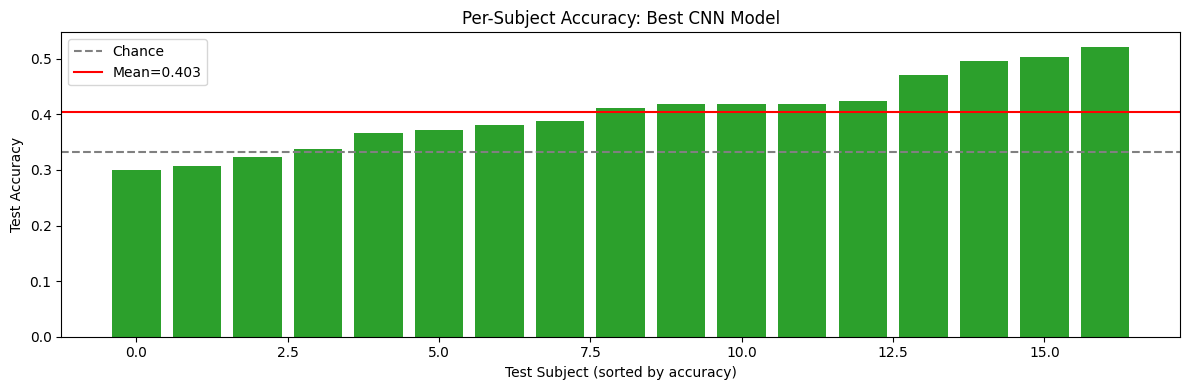

Best subject: 0.521
Worst subject: 0.301
Mean: 0.403
Subjects above chance: 14/17


In [13]:
# Per-subject accuracy analysis
test_subject_ids = subjects_bal[test_mask]
best_model = models["CNN"] 
best_model.eval()

subject_accs = {}
for subj in np.unique(test_subject_ids):
    subj_mask = test_subject_ids == subj
    X_s = X_test_t[subj_mask]
    y_s = y_test_t[subj_mask]
    with torch.no_grad():
        preds = best_model(X_s.to(device)).argmax(1).cpu()
    acc = (preds == y_s).float().mean().item()
    subject_accs[subj] = acc

# Plot
plt.figure(figsize=(12, 4))
subjs = list(subject_accs.keys())
accs  = list(subject_accs.values())
plt.bar(range(len(subjs)), sorted(accs), color='tab:green')
plt.axhline(0.333, color='gray', linestyle='--', label='Chance')
plt.axhline(np.mean(accs), color='red', linestyle='-', label=f'Mean={np.mean(accs):.3f}')
plt.xlabel("Test Subject (sorted by accuracy)")
plt.ylabel("Test Accuracy")
plt.title("Per-Subject Accuracy: Best CNN Model")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_subject_accuracy.png'), dpi=150)
plt.show()

print(f"Best subject: {max(accs):.3f}")
print(f"Worst subject: {min(accs):.3f}")
print(f"Mean: {np.mean(accs):.3f}")
print(f"Subjects above chance: {sum(a > 0.333 for a in accs)}/{len(accs)}")